# Optimising a wireless inductive charger for a mobile phone

*TIPE — two-year research project in French* classes préparatoires *(MP\*), Lycée Pasteur, 2024–2025.*
Ethan Ben Denoun · [personal page](https://ethanbendenoun.github.io/) · [repository](https://github.com/ethanbendenoun/tipe-wireless-power-transfer)

**Question.** How can the transfer efficiency of an inductive phone charger be maximised?

**What this notebook is.** The five experiments of the project, retraced from the raw measurements
(`data/`). Every point below was read on an oscilloscope and typed into Regressi during the sessions of
May 2025; nothing is simulated. The theoretical part of the project — Biot–Savart field of the coils,
transfer function of the resonant coupling, Bode diagrams, Graetz bridge rectification and the Qi
protocol — is in the oral presentation and is only summarised here.

## Set-up and definition of efficiency

Two flat coils face each other: an emitting coil driven by a function generator at input voltage
$V_e = 5\,\mathrm{V}$, and a receiving coil closed on a load. The same resistance $R$ is used as
current-sense resistor in the primary and as load in the secondary, so that

$$
P_\text{in} = \frac{V_e\, V_{pp1}}{R}, \qquad
P_\text{out} = \frac{V_{pp2}^2}{R}, \qquad
r = \frac{P_\text{out}}{P_\text{in}} = \frac{V_{pp2}^{2}}{V_{pp1}\, V_e},
$$

where $V_{pp1}$ and $V_{pp2}$ are the peak-to-peak voltages measured across the primary sense resistor
and across the load. **All efficiencies in this notebook use this definition.** It is the one recorded in
the Regressi files, and it neglects the phase between voltage and current in the primary — see the
*Limits* section.

Three configurations were compared, then the geometry was varied on the resonant set-up:

1. non-resonant coupling — the two coils alone;
2. resonant coupling — a capacitor in series on each side, tuned to the same frequency;
3. resonant coupling with a ferromagnetic core between the coils.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Data are read from the repository; fall back to the raw GitHub files (e.g. in Colab).
DATA = Path("data") if Path("data").exists() else "https://raw.githubusercontent.com/ethanbendenoun/tipe-wireless-power-transfer/main/data/"

def load(name):
    return pd.read_csv(f"{DATA}/{name}")

sweeps = {
    "non-resonant coupling":          load("efficiency_vs_frequency_non_resonant.csv"),
    "resonant coupling":              load("efficiency_vs_frequency_resonant.csv"),
    "resonant + ferromagnetic core":  load("efficiency_vs_frequency_resonant_ferrite.csv"),
}
misalignment = load("efficiency_vs_misalignment.csv")
separation   = load("efficiency_vs_distance.csv")

for name, df in sweeps.items():
    best = df.loc[df["r"].idxmax()]
    print(f"{name:32s} {len(df):2d} points   max r = {100*best['r']:5.1f} %  at {best['f_Hz']/1e3:g} kHz")

non-resonant coupling            28 points   max r =   3.7 %  at 60 kHz
resonant coupling                28 points   max r =  12.6 %  at 29 kHz
resonant + ferromagnetic core    41 points   max r =  97.2 %  at 17 kHz


## 1. Non-resonant, resonant, and resonant with a ferromagnetic core

Efficiency against the driving frequency, for the three configurations.

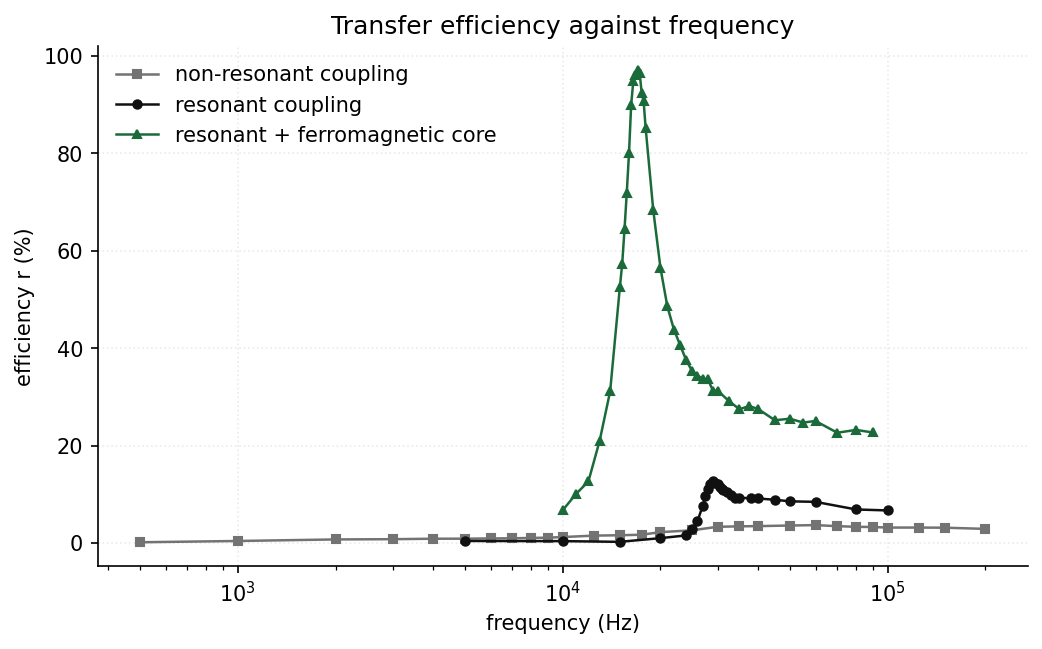

In [ ]:
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": ":"})
GREEN, GREY, BLACK = "#1B6B3A", "#737373", "#111111"

fig, ax = plt.subplots(figsize=(8, 4.5))
for (name, df), c, m in zip(sweeps.items(), [GREY, BLACK, GREEN], ["s", "o", "^"]):
    ax.semilogx(df["f_Hz"], 100 * df["r"], marker=m, ms=4, lw=1.2, color=c, label=name)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("efficiency r (%)")
ax.set_title("Transfer efficiency against frequency")
ax.legend(frameon=False)
plt.show()

**Reading the curves.**

- *Non-resonant coupling* transfers very little: the efficiency rises slowly with frequency and
  saturates around **3.7 % at 60 kHz**. The coupling coefficient between two loosely coupled air coils
  is small, and most of the primary current only builds up the leakage field.
- *Resonant coupling* adds a sharp peak: **12.6 % at 29 kHz**, at the common resonance frequency of
  the two $LC$ circuits, then falls back to the non-resonant level away from it. Resonance compensates
  the reactive part of the impedance, so the current in the secondary is limited by the resistance only.
- *Adding a ferromagnetic core* does two things. It raises the mutual inductance, and it raises the
  self-inductance of each coil, which moves the resonance down from 29 kHz to
  $f_0 = 1/(2\pi\sqrt{LC}) \approx$ **17 kHz**. At that frequency the measured efficiency reaches
  **97 % by the definition above**.

That last value should be read with its definition in mind: $r$ compares the power dissipated in the
load to $V_e V_{pp1}/R$, which overestimates the input power if the primary current is not in phase with
$V_e$ — at resonance the phase is close to zero, which is precisely when the definition is at its best,
but the value is an upper bound rather than a wall-plug efficiency.

## 2. Effect of the coil geometry

On the resonant set-up, driven at its resonance frequency, the receiving coil was then moved:
laterally (misalignment), and away from the emitting coil (separation).

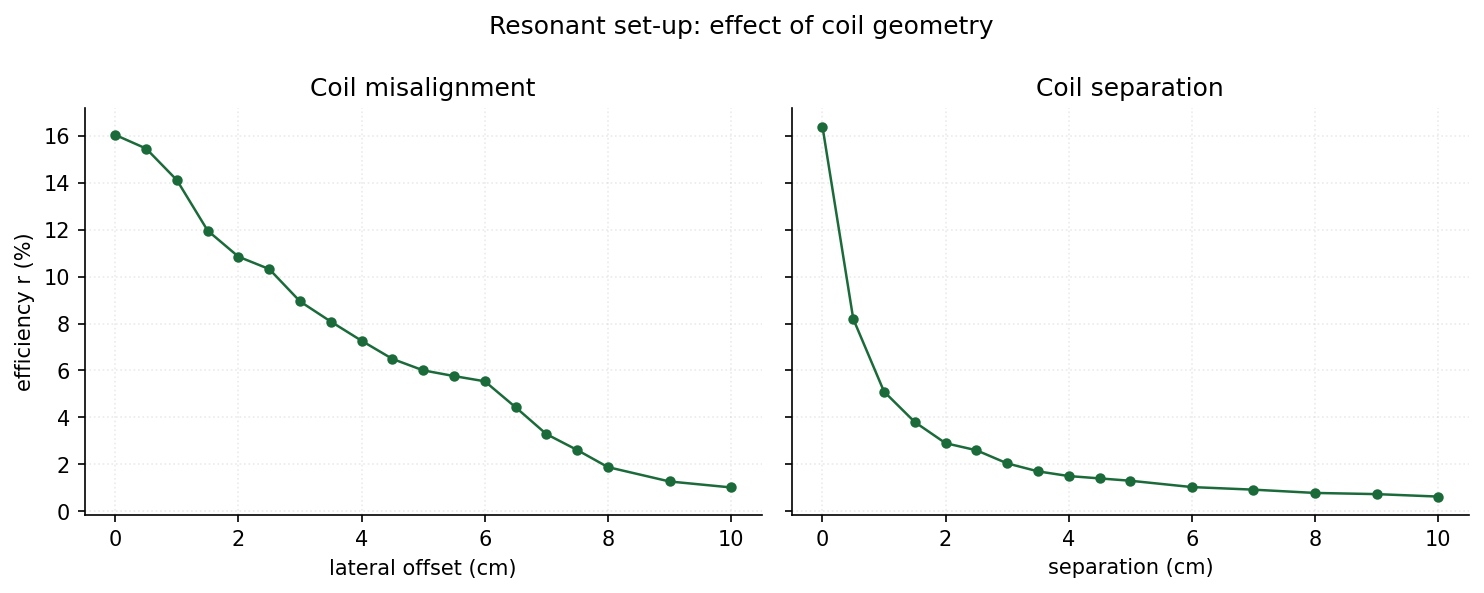

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].plot(misalignment["d_cm"], 100 * misalignment["r"], marker="o", ms=4, lw=1.2, color=GREEN)
axes[0].set_xlabel("lateral offset (cm)"); axes[0].set_title("Coil misalignment")
axes[1].plot(separation["d_cm"], 100 * separation["r"], marker="o", ms=4, lw=1.2, color=GREEN)
axes[1].set_xlabel("separation (cm)"); axes[1].set_title("Coil separation")
axes[0].set_ylabel("efficiency r (%)")
fig.suptitle("Resonant set-up: effect of coil geometry")
plt.tight_layout()
plt.show()

**Reading the curves.**

- *Misalignment* degrades the transfer almost **linearly**: from 16 % when the coils are centred to
  about half of that at 4 cm of offset, and 1 % at 10 cm. The mutual inductance follows the overlap
  of the two coil areas, which decreases roughly linearly with the offset for coils of this size.
- *Separation* is far more punishing: the efficiency is **halved within the first 5 mm**, and is
  below 3 % beyond 2 cm. The field of a flat coil on its axis decays quickly with distance, and the
  mutual inductance with it.

This is the practical trade-off behind every phone charger: the receiver must sit almost against the
emitter, but does not need to be perfectly centred — hence flat pads and, in commercial chargers, the
Qi protocol adjusting the transmitted power to what the receiver reports.

## Limits

- **Manual readings.** Every point is a peak-to-peak voltage read on an oscilloscope screen and typed
  in; no uncertainty was recorded (the Regressi files carry none). Expect a few percent of relative
  error on each point, more near the resonance where the curve is steep.
- **Different sessions.** The frequency sweeps were taken on 20 May, the geometry sweeps on 22 May,
  after the set-up had been re-tuned: the geometry curves start at 16 % where the resonant sweep peaks
  at 12.6 %. Compare shapes across figures, not absolute levels.
- **Definition of $r$.** As discussed above, $r$ neglects the phase in the primary; the 97 % figure is
  an upper bound under that definition, not an end-to-end efficiency.
- **Not measured here.** The Bode diagrams of the transfer function, the Graetz-bridge rectification
  and the Qi protocol simulation belong to the presentation and were not recorded as data files.

## Files

| Path | Content |
|---|---|
| `data/efficiency_vs_frequency_non_resonant.csv` | frequency sweep, coils alone |
| `data/efficiency_vs_frequency_resonant.csv` | frequency sweep, series capacitors |
| `data/efficiency_vs_frequency_resonant_ferrite.csv` | frequency sweep with core; includes $V_{pp1}$, $V_{pp2}$ |
| `data/efficiency_vs_misalignment.csv` | lateral offset, resonant set-up |
| `data/efficiency_vs_distance.csv` | separation, resonant set-up |
| `data/raw/*.rw3` | the original Regressi files, untouched |

The CSV files are a direct export of the `.rw3` files; the column `r` of the ferrite sweep is
recomputed from $V_{pp1}$ and $V_{pp2}$ with the definition above.